# DSC640-T302 Data Presentation & Visualization (2261-1)
## Weeks 1 & 2 Project Milestone 1
### Linh Huynh

In [18]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [20]:
import pandas as pd
df = pd.read_excel('/Users/linhhuynh/Desktop/DSC640/Dataset/nationaldatabaseofchildcareprices.xlsx')
df.head(5)

,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.42,4.41,6.32,4.6,3.5,...,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.0,1.0
1,Alabama,AL,Autauga County,1001,2009,5.93,5.72,6.11,4.8,4.6,...,87.39,3.0,85.68,1.0,102.0,1.0,102.0,3.0,100.0,1.0
2,Alabama,AL,Autauga County,1001,2010,6.21,5.57,6.78,5.1,4.6,...,91.33,3.0,89.96,1.0,106.6,1.0,106.6,3.0,105.0,1.0
3,Alabama,AL,Autauga County,1001,2011,7.55,8.13,7.03,6.2,6.3,...,95.28,3.0,94.25,1.0,111.2,1.0,111.2,3.0,110.0,1.0
4,Alabama,AL,Autauga County,1001,2012,8.60,8.88,8.29,6.7,6.4,...,99.22,3.0,98.53,1.0,115.8,1.0,115.8,3.0,115.0,1.0


In [22]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Pick price columns 
price_cols = [c for c in df.columns
              if re.search(r"(Infant|Toddler|Preschool)", c, re.I)
              and not re.search(r"flag", c, re.I)]

In [24]:
# Quick summary
print("Rows/Cols:", df.shape)
print("Example price cols:", price_cols[:8])
print(df[price_cols].describe().T)

Rows/Cols: (34567, 227)
Example price cols: ['MCInfant', 'MCToddler', 'MCPreschool', '_75CInfant', '_75CToddler', '_75CPreschool', 'MFCCInfant', 'MFCCToddler']
                   count        mean        std    min      25%     50%  \
MCInfant         23593.0  146.051770  53.698566  27.73  108.750  134.50   
MCToddler        23593.0  130.482768  43.775370  21.54  100.000  120.99   
MCPreschool      23593.0  122.232852  38.538323  21.54   95.880  113.99   
_75CInfant       23593.0  165.926607  62.889701  32.18  123.700  150.00   
_75CToddler      23593.0  149.213983  52.236542  25.00  113.580  137.40   
_75CPreschool    23593.0  140.386184  46.337349  25.00  108.900  129.45   
MFCCInfant       23383.0  113.421657  32.819372  43.08   90.000  106.00   
MFCCToddler      23383.0  106.759749  29.982431  43.08   85.085  100.25   
MFCCPreschool    23383.0  104.189510  28.961701  40.03   84.255   99.65   
_75FCCInfant     23383.0  128.909289  38.543010  50.00  100.830  123.15   
_75FCCToddler  

In [26]:
# Reshape for plots
id_cols = [c for c in ["StudyYear"] if c in df.columns]
long = df[id_cols + price_cols].melt(id_vars=id_cols or None,
                                     value_vars=price_cols,
                                     var_name="measure", value_name="price")

long["age"] = long["measure"].str.extract(r"(Infant|Toddler|Preschool)", expand=False)
long["provider"] = (
    long["measure"].str.contains("FCC", case=False).map({True:"Family (FCC)", False:""})
    .where(~long["measure"].str.contains("CCC", case=False), "Center (CCC)")
    .replace("", "Unknown")
)

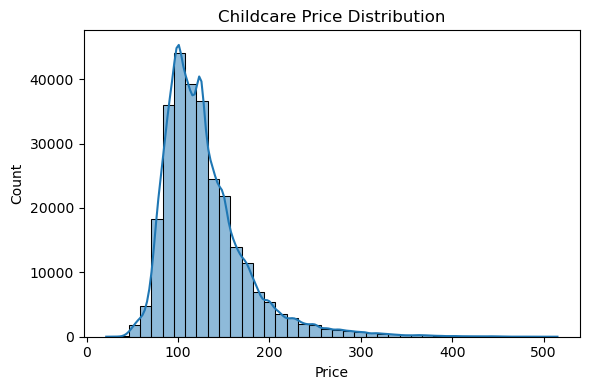

In [28]:
# Plot: Distribution (all prices)
plt.figure(figsize=(6,4))
sns.histplot(long["price"], bins=40, kde=True)
plt.title("Childcare Price Distribution")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

This chart shows how much parents usually pay for childcare. Most prices are between 100 dollars and 150 dollars, which means this is the common range for many families. A smaller number of places charge much more, sometimes over 300 dollars - 500 dollars, but these are less common. The curve line also shows that prices rise quickly up to about $120 and then slowly go down, meaning some centers are very expensive but not the majority. This tells us that while most families pay around the middle range, a few pay much higher costs depending on location or type of care.


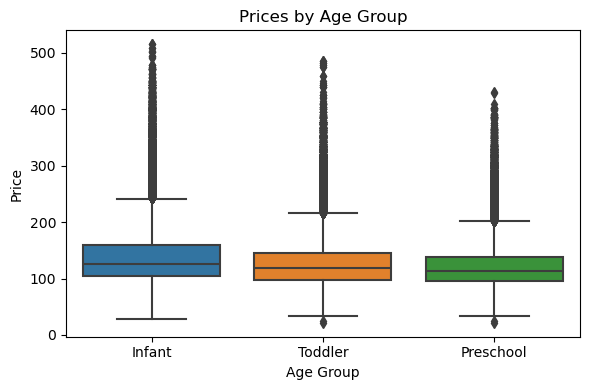

In [31]:
# Age comparison (boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(data=long, x="age", y="price")
plt.title("Prices by Age Group")
plt.xlabel("Age Group"); plt.ylabel("Price")
plt.tight_layout()
plt.show()

This chart compares childcare prices for infants, toddlers, and preschoolers. Infant care is usually the most expensive, with a higher middle price than the other groups. Toddler and preschool care cost a little less, and their typical prices look very similar to each other. Most families pay between 100 dollars and 150 dollars for all groups, but there are some places that charge much more, especially for infants. These very high prices are shown as the many dots above the boxes, meaning they are less common but still present.


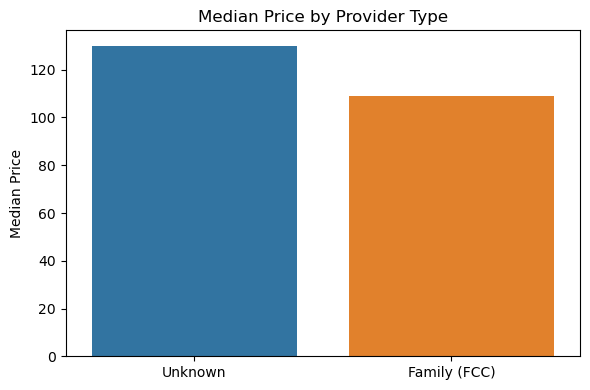

In [34]:
# Provider comparison (median bar)
prov = long.groupby("provider", as_index=False)["price"].median().sort_values("price", ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(data=prov, x="provider", y="price")
plt.title("Median Price by Provider Type")
plt.xlabel(""); plt.ylabel("Median Price")
plt.tight_layout()
plt.show()

This chart compares the median childcare price by provider type. It shows that family childcare (FCC) has a lower median cost, around 110 dollar, while the group marked as unknown has a higher median price, about 130 dollar. This suggests that family-based providers are usually a bit cheaper than other types of care. However, since one group is labeled “unknown”, it may include centers or mixed providers that were not clearly identified, which could explain the higher price.


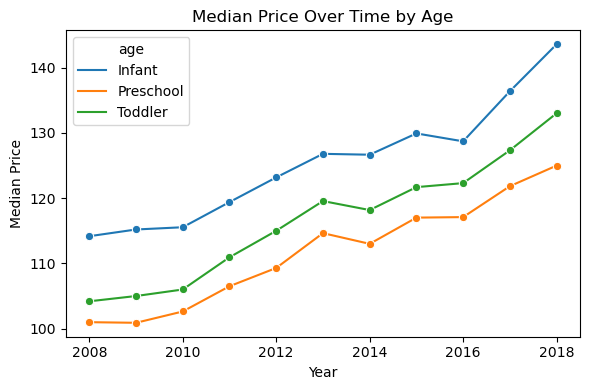

In [37]:
# Trend over time by age 
if "StudyYear" in long.columns:
    trend = (long.dropna(subset=["price","StudyYear"])
                  .groupby(["StudyYear","age"], as_index=False)["price"].median())
    plt.figure(figsize=(6,4))
    sns.lineplot(data=trend, x="StudyYear", y="price", hue="age", marker="o")
    plt.title("Median Price Over Time by Age")
    plt.xlabel("Year"); plt.ylabel("Median Price")
    plt.tight_layout()
    plt.show()

This chart shows how childcare prices have changed over time for infants, toddlers, and preschoolers. From 2008 dollars to 2018 dollars, prices have gone up for all age groups. Infant care is always the most expensive, starting around 115 dollars in 2008 and rising to more than 140 dollars by 2018. Toddler care is in the middle, while preschool is the cheapest, but both also increased steadily. The gap between infants and older children stays clear across all years. This means that childcare costs keep rising no matter the age, and families with infants usually face the highest costs.
